# HMM Ranking Model Evaluation
- Replicates paper's setup: n_states = n_emissions = n_modules
- Runs experiments across multiple random train/validation splits to get more reliable results
- Consistent evaluation pipeline for all experiments so results are easy to compare

In [1]:
import math
import numpy as np
import pandas as pd
import warnings
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from typing import List, Dict

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

RANDOM_SEED = 739284
N_MODULES = 20
TEST_FRACTION = 0.1  # 10% test set
N_SPLITS = 10  # Multiple random splits per experiment

np.random.seed(RANDOM_SEED)
print(f"Config: {N_MODULES} modules, {N_SPLITS} splits per experiment")

Config: 20 modules, 10 splits per experiment


## Data Preparation Functions

In [2]:
def load_gene_sets(filepath: str) -> List[List[str]]:
    """Load and parse gene sets."""
    df = pd.read_csv(filepath, sep='\t')
    return [genes.split(', ') for genes in df['genes'] if ', ' in genes]

def calculate_mwt(gene_set: List[str], data: pd.DataFrame) -> float:
    """Calculate Moderated Welch Test statistic."""
    high = data[data['high_risk'] == True][gene_set]
    low = data[data['high_risk'] == False][gene_set]
    
    h_means, l_means = high.mean(axis=1).values, low.mean(axis=1).values
    h_vars, l_vars = high.var(axis=1, ddof=1).values, low.var(axis=1, ddof=1).values
    n_h, n_l = len(h_means), len(l_means)
    
    # Variance moderation
    all_vars = np.concatenate([h_vars, l_vars])
    prior_var, prior_df = np.median(all_vars[all_vars > 0]), 4
    mod_h = (prior_df * prior_var + (n_h - 1) * h_vars.mean()) / (prior_df + n_h - 1)
    mod_l = (prior_df * prior_var + (n_l - 1) * l_vars.mean()) / (prior_df + n_l - 1)
    
    mean_diff = h_means.mean() - l_means.mean()
    se = np.sqrt(mod_h / n_h + mod_l / n_l)
    return abs(mean_diff / se) if se > 0 else 0

def select_top_gene_sets(all_sets: List[List[str]], data: pd.DataFrame, n: int):
    """Select top n gene sets by MWT statistic."""
    scores = [(i, calculate_mwt(gs, data), gs) for i, gs in enumerate(all_sets)]
    df = pd.DataFrame(scores, columns=['idx', 'mwt', 'gene_set']).sort_values('mwt', ascending=False)
    return df['gene_set'].head(n).tolist()

def calculate_module_scores(data: pd.DataFrame, gene_sets: List[List[str]]):
    """Calculate t-statistic module scores."""
    df = data.copy()
    modules = []
    for i, gs in enumerate(gene_sets):
        mod = f'Module_{i+1}'
        modules.append(mod)
        tmp = df[gs]
        df[mod] = math.sqrt(len(gs)) * tmp.mean(axis=1) / tmp.std(axis=1)
    return df, modules

def rank_modules(data: pd.DataFrame, modules: List[str], shuffle=False):
    """Convert module scores to rankings."""
    mods = modules.copy()
    if shuffle:
        np.random.shuffle(mods)
    
    ranks = data[mods].apply(lambda row: row.rank(method='first'), axis=1)
    ranks.columns = modules  # Keep original module names
    return pd.concat([ranks, data[['PATIENT_ID', 'high_risk']]], axis=1)

## HMM Core Functions

In [3]:
def train_hmm(train_data: pd.DataFrame, n_modules: int):
    """Train emission probabilities. States = Emissions = n_modules."""
    high = train_data[train_data['high_risk'] == True].drop(columns=['PATIENT_ID', 'high_risk'])
    low = train_data[train_data['high_risk'] == False].drop(columns=['PATIENT_ID', 'high_risk'])
    
    em_h = np.zeros((n_modules, n_modules))
    em_l = np.zeros((n_modules, n_modules))
    
    for state in range(n_modules):
        for mod_idx in range(n_modules):
            col = f'Module_{mod_idx + 1}'
            em_h[state][mod_idx] = (high[col] == state + 1).sum() / len(high)
            em_l[state][mod_idx] = (low[col] == state + 1).sum() / len(low)
    
    return em_h, em_l

def predict_hmm(ranks: List[int], em_h: np.ndarray, em_l: np.ndarray):
    """Predict using Forward algorithm."""
    n = len(em_h)
    start = np.array([1.0] + [0.0]*(n-1))
    trans = np.eye(n, k=1)  # Deterministic transitions
    
    fwd_h = np.zeros((n, n))
    fwd_l = np.zeros((n, n))
    
    for t in range(n):
        obs_mod = next((i for i, r in enumerate(ranks) if r == t+1), 0)
        
        for s in range(n):
            if t == 0:
                fwd_h[s][t] = start[s]
                fwd_l[s][t] = start[s]
            else:
                fwd_h[s][t] = sum(fwd_h[prev][t-1] * trans[prev][s] for prev in range(n))
                fwd_l[s][t] = sum(fwd_l[prev][t-1] * trans[prev][s] for prev in range(n))
            
            fwd_h[s][t] *= em_h[s][obs_mod]
            fwd_l[s][t] *= em_l[s][obs_mod]
    
    prob_h = fwd_h[:, -1].sum()
    prob_l = fwd_l[:, -1].sum()
    prob_high = prob_h / (prob_h + prob_l + 1e-300)
    
    return prob_h > prob_l, np.log(max(prob_h, prob_l) + 1e-300), prob_high

def evaluate(preds: pd.DataFrame) -> Dict:
    """Calculate metrics."""
    tp = ((preds['high_risk']) & (preds['pred'])).sum()
    tn = ((~preds['high_risk']) & (~preds['pred'])).sum()
    fp = ((~preds['high_risk']) & (preds['pred'])).sum()
    fn = ((preds['high_risk']) & (~preds['pred'])).sum()
    
    denom = math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc = (tp*tn - fp*fn) / denom if denom > 0 else 0
    auc = roc_auc_score(preds['high_risk'], preds['prob_high'])
    acc = (tp + tn) / len(preds)
    
    return {'AUC': auc, 'MCC': mcc, 'Accuracy': acc, 'TP': int(tp), 
            'TN': int(tn), 'FP': int(fp), 'FN': int(fn)}

## Experiment Framework

In [4]:
def run_experiment(rank_data: pd.DataFrame, n_modules: int, test_frac: float):
    """Single train/test run."""
    data = rank_data.sample(frac=1).reset_index(drop=True)
    split_idx = int(len(data) * (1 - test_frac))
    train, test = data.iloc[:split_idx], data.iloc[split_idx:]
    
    em_h, em_l = train_hmm(train, n_modules)
    
    results = []
    for _, row in test.iterrows():
        ranks = [row[f'Module_{i+1}'] for i in range(n_modules)]
        pred, ll, ph = predict_hmm(ranks, em_h, em_l)
        results.append({'PATIENT_ID': row['PATIENT_ID'], 'high_risk': row['high_risk'],
                       'pred': pred, 'loglik': ll, 'prob_high': ph})
    
    return evaluate(pd.DataFrame(results))

def run_multiple_splits(rank_data: pd.DataFrame, n_modules: int, n_splits: int, test_frac: float):
    """Run multiple splits and return results DataFrame."""
    return pd.DataFrame([run_experiment(rank_data, n_modules, test_frac) for _ in range(n_splits)])

def print_summary(results: pd.DataFrame, title: str):
    for m in ['AUC', 'MCC', 'Accuracy']:
        print(f"{m:8s}: {results[m].mean():.4f} ± {results[m].std():.4f} "
              f"[{results[m].min():.4f}, {results[m].max():.4f}]")
    
    summary_dict = {}
    for m in ['AUC', 'MCC', 'Accuracy']:
        summary_dict[f'{m}_mean'] = results[m].mean()
        summary_dict[f'{m}_std'] = results[m].std()
    return summary_dict

def plot_results(results: pd.DataFrame, title: str):
    """Visualize results variability."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for idx, (m, c) in enumerate(zip(['AUC', 'MCC', 'Accuracy'], ['blue', 'orange', 'green'])):
        vals = results[m].values
        axes[idx].boxplot([vals], widths=0.6, patch_artist=True,
                         boxprops=dict(facecolor=c, alpha=0.3))
        axes[idx].scatter(1 + np.random.normal(0, 0.04, len(vals)), vals, 
                         alpha=0.6, s=80, color=c, edgecolors='black', linewidth=0.5)
        axes[idx].axhline(vals.mean(), color='red', linestyle='--', linewidth=2)
        axes[idx].set_title(f"{m}\n{title}")
        axes[idx].set_xlim(0.5, 1.5)
        axes[idx].set_xticks([1])
        axes[idx].set_xticklabels([''])
        axes[idx].grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## Load and Prepare Data

In [5]:
# Load data
print("Loading data...")
raw = pd.read_csv("merged.csv")
all_sets = load_gene_sets('enrich-input1-GO_BP.tsv')
all_genes = list(set([g for gs in all_sets for g in gs]))
temp = raw[all_genes + ['PATIENT_ID', 'high_risk']]

print(f"Loaded {len(all_sets)} gene sets, {raw.shape[0]} patients")
print(f"High risk: {raw['high_risk'].sum()}, Low risk: {(~raw['high_risk']).sum()}")

Loading data...
Loaded 191 gene sets, 764 patients
High risk: 222, Low risk: 542


## Experiment 1: Baseline Performance

AUC     : 0.5974 ± 0.0484 [0.5170, 0.6737]
MCC     : 0.1514 ± 0.0799 [0.0346, 0.2920]
Accuracy: 0.6052 ± 0.0442 [0.5325, 0.6623]


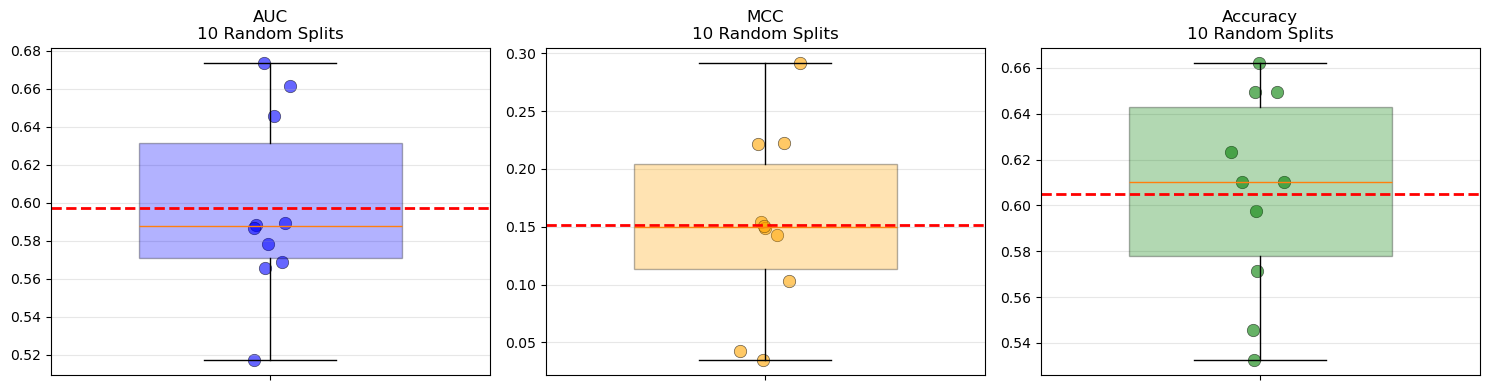

In [6]:
# Select top gene sets
sets = select_top_gene_sets(all_sets, temp, N_MODULES)
genes = list(set([g for gs in sets for g in gs]))
data = raw[genes + ['PATIENT_ID', 'high_risk']].copy()

# Calculate module scores and ranks
data, modules = calculate_module_scores(data, sets)
rank_data = rank_modules(data, modules)

exp1_results = run_multiple_splits(rank_data, N_MODULES, N_SPLITS, TEST_FRACTION)
exp1_summary = print_summary(exp1_results, f"Baseline: {N_MODULES} Modules")
plot_results(exp1_results, f"{N_SPLITS} Random Splits")

## Experiment 2: Sensitivity to Number of Hidden States (Modules)

In [7]:
MODULE_COUNTS = [2, 3, 5, 7, 10, 12, 15, 20, 25, 30]
exp2_results = []

print(f"\nTesting different module counts with {N_SPLITS} splits each...")
for n_mod in MODULE_COUNTS:
    # Prepare data for this module count
    sets_n = select_top_gene_sets(all_sets, temp, n_mod)
    genes_n = list(set([g for gs in sets_n for g in gs]))
    data_n = raw[genes_n + ['PATIENT_ID', 'high_risk']].copy()
    data_n, mods_n = calculate_module_scores(data_n, sets_n)
    rank_n = rank_modules(data_n, mods_n)
    
    # Run splits
    results = run_multiple_splits(rank_n, n_mod, N_SPLITS, TEST_FRACTION)
    
    for m in ['AUC', 'MCC', 'Accuracy']:
        exp2_results.append({
            'n_modules': n_mod,
            'metric': m,
            'mean': results[m].mean(),
            'std': results[m].std(),
            'min': results[m].min(),
            'max': results[m].max()
        })
    
    print(f"  {n_mod} modules: AUC={results['AUC'].mean():.4f}±{results['AUC'].std():.4f}")

exp2_df = pd.DataFrame(exp2_results)


Testing different module counts with 10 splits each...
  2 modules: AUC=0.5269±0.0790
  3 modules: AUC=0.5299±0.0580
  5 modules: AUC=0.5209±0.0583
  7 modules: AUC=0.4662±0.0737
  10 modules: AUC=0.6196±0.0528
  12 modules: AUC=0.5601±0.0814
  15 modules: AUC=0.6256±0.0583
  20 modules: AUC=0.5846±0.0675
  25 modules: AUC=0.5466±0.0839
  30 modules: AUC=0.5419±0.0592


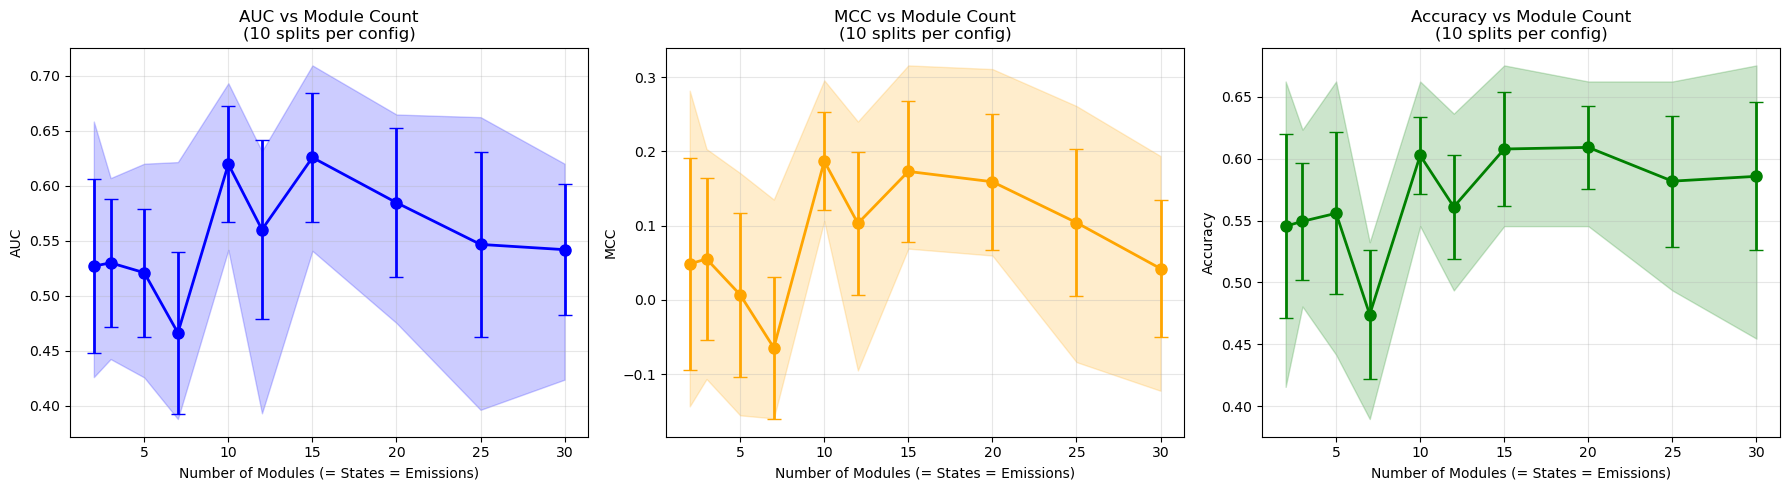


Best AUC: 15 modules (0.6256±0.0583)


In [8]:
# Plot module count sensitivity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (m, c) in enumerate(zip(['AUC', 'MCC', 'Accuracy'], ['blue', 'orange', 'green'])):
    df_m = exp2_df[exp2_df['metric'] == m]
    axes[idx].errorbar(df_m['n_modules'], df_m['mean'], yerr=df_m['std'],
                      marker='o', capsize=5, linewidth=2, markersize=8, color=c)
    axes[idx].fill_between(df_m['n_modules'], df_m['min'], df_m['max'], alpha=0.2, color=c)
    axes[idx].set_xlabel('Number of Modules (= States = Emissions)')
    axes[idx].set_ylabel(m)
    axes[idx].set_title(f'{m} vs Module Count\n({N_SPLITS} splits per config)')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_auc = exp2_df[exp2_df['metric']=='AUC'].loc[exp2_df[exp2_df['metric']=='AUC']['mean'].idxmax()]
print(f"\nBest AUC: {best_auc['n_modules']:.0f} modules ({best_auc['mean']:.4f}±{best_auc['std']:.4f})")

## Experiment 3: Performance on Synthetic Data

AUC     : 0.4934 ± 0.0600 [0.4002, 0.5744]
MCC     : -0.0184 ± 0.0980 [-0.1455, 0.1032]
Accuracy: 0.4930 ± 0.0469 [0.4300, 0.5500]


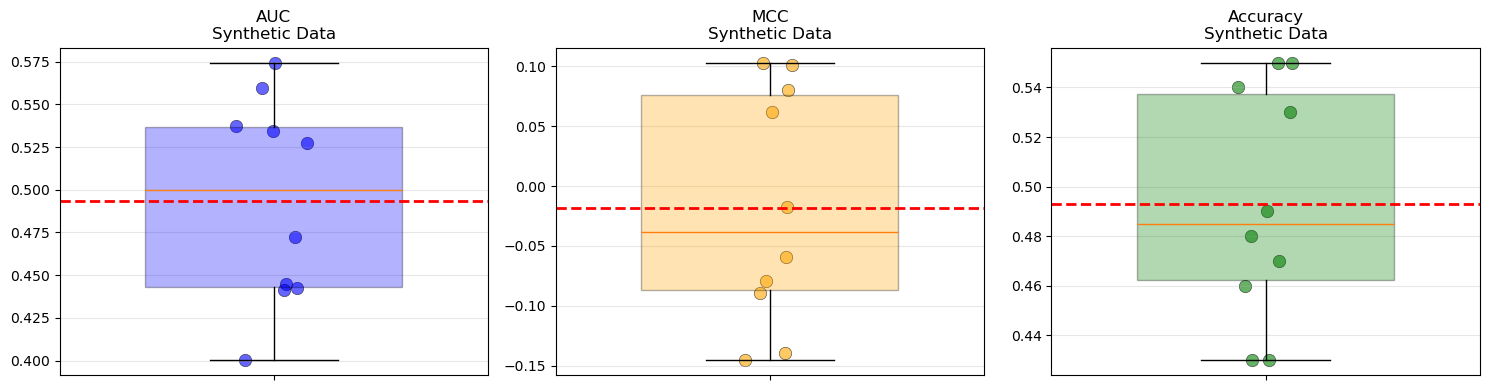


Comparison - Real vs Synthetic AUC:
Real: 0.5974 ± 0.0484
Synthetic: 0.4934 ± 0.0600


In [ ]:
def generate_synthetic(n_samples: int, n_modules: int, high_ratio: float = 0.5):
    """Generate synthetic ranking data with distinct patterns."""
    n_high = int(n_samples * high_ratio)
    data = []
    
    # High risk: beta(2,5) distribution
    for i in range(n_high):
        weights = np.random.beta(2, 5, n_modules)
        ranks = np.argsort(weights) + 1
        row = {f'Module_{j+1}': int(ranks[j]) for j in range(n_modules)}
        row.update({'PATIENT_ID': f'SYN_H_{i}', 'high_risk': True})
        data.append(row)
    
    # Low risk: beta(5,2) distribution
    for i in range(n_samples - n_high):
        weights = np.random.beta(5, 2, n_modules)
        ranks = np.argsort(weights) + 1
        row = {f'Module_{j+1}': int(ranks[j]) for j in range(n_modules)}
        row.update({'PATIENT_ID': f'SYN_L_{i}', 'high_risk': False})
        data.append(row)
    
    return pd.DataFrame(data)

# Generate and test
synth_data = generate_synthetic(500, N_MODULES)
exp3_results = run_multiple_splits(synth_data, N_MODULES, N_SPLITS, TEST_FRACTION)
exp3_summary = print_summary(exp3_results, f"Synthetic Data ({N_MODULES} modules)")
plot_results(exp3_results, "Synthetic Data")

print(f"\nComparison - Real vs Synthetic AUC:")
print(f"Real: {exp1_summary['AUC_mean']:.4f} ± {exp1_summary['AUC_std']:.4f}")
print(f"Synthetic: {exp3_summary['AUC_mean']:.4f} ± {exp3_summary['AUC_std']:.4f}")

## Experiment 4: Impact of Gene Set Ordering

In [10]:
N_SHUFFLE_TRIALS = 10
exp4_results = {'Original': exp1_results}

print(f"\nTesting {N_SHUFFLE_TRIALS} shuffled orderings...")
for trial in range(N_SHUFFLE_TRIALS):
    rank_shuffled = rank_modules(data, modules, shuffle=True)
    results = run_multiple_splits(rank_shuffled, N_MODULES, N_SPLITS, TEST_FRACTION)
    exp4_results[f'Shuffle_{trial+1}'] = results
    print(f"  Trial {trial+1}: AUC={results['AUC'].mean():.4f}±{results['AUC'].std():.4f}")

# Aggregate shuffled results
shuffled_aucs = np.concatenate([exp4_results[k]['AUC'].values 
                                 for k in exp4_results if k != 'Original'])
orig_auc = exp1_results['AUC'].mean()

print(f"\nOriginal: {orig_auc:.4f}")
print(f"Shuffled: {shuffled_aucs.mean():.4f} ± {shuffled_aucs.std():.4f}")
print(f"Difference: {orig_auc - shuffled_aucs.mean():+.4f}")


Testing 10 shuffled orderings...
  Trial 1: AUC=0.5407±0.0949
  Trial 2: AUC=0.6085±0.0817
  Trial 3: AUC=0.5688±0.0588
  Trial 4: AUC=0.5913±0.0734
  Trial 5: AUC=0.5682±0.0473
  Trial 6: AUC=0.5675±0.0612
  Trial 7: AUC=0.5847±0.0927
  Trial 8: AUC=0.5661±0.0782
  Trial 9: AUC=0.5524±0.0994
  Trial 10: AUC=0.5519±0.0529

Original: 0.5974
Shuffled: 0.5700 ± 0.0747
Difference: +0.0274


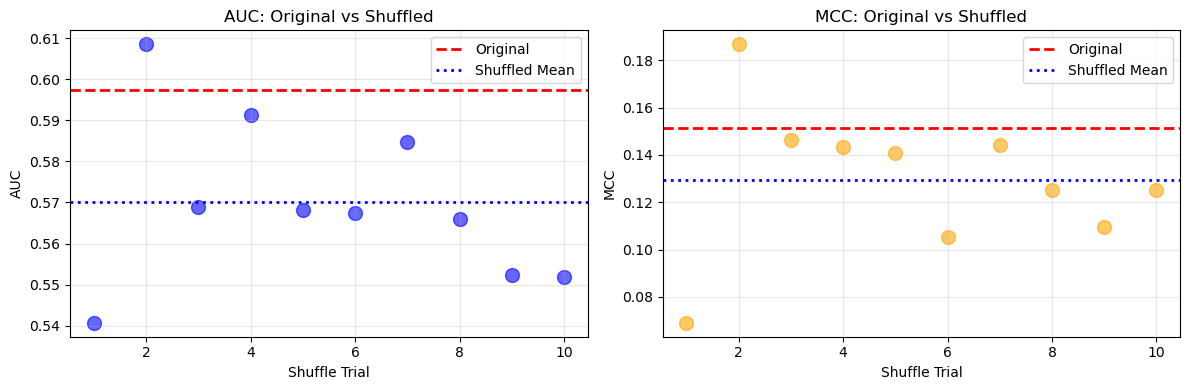

In [11]:
# Visualize ordering impact
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, (m, c) in enumerate(zip(['AUC', 'MCC'], ['blue', 'orange'])):
    orig = exp1_results[m].mean()
    shuf_vals = [exp4_results[k][m].mean() for k in exp4_results if k != 'Original']
    
    axes[idx].axhline(orig, color='red', linestyle='--', linewidth=2, label='Original')
    axes[idx].scatter(range(1, len(shuf_vals)+1), shuf_vals, s=100, alpha=0.6, color=c)
    axes[idx].axhline(np.mean(shuf_vals), color='blue', linestyle=':', linewidth=2, label='Shuffled Mean')
    axes[idx].set_xlabel('Shuffle Trial')
    axes[idx].set_ylabel(m)
    axes[idx].set_title(f'{m}: Original vs Shuffled')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

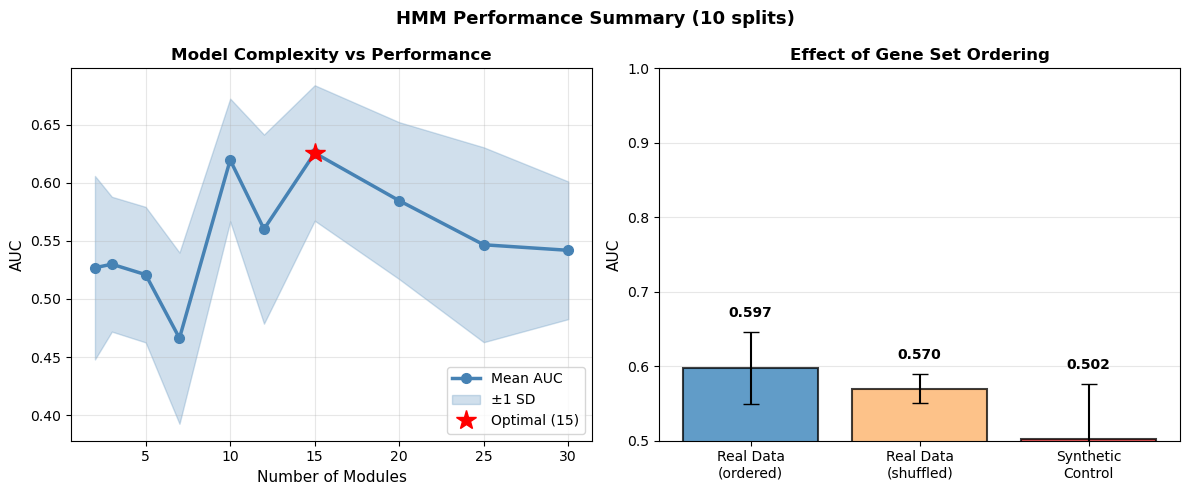

In [12]:
# Create summary figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'HMM Performance Summary ({N_SPLITS} splits)', fontsize=13, fontweight='bold')

# Left: Module count effect on AUC
df_auc = exp2_df[exp2_df['metric'] == 'AUC']
axes[0].plot(df_auc['n_modules'], df_auc['mean'], 'o-', linewidth=2.5, 
             markersize=7, color='steelblue', label='Mean AUC')
axes[0].fill_between(df_auc['n_modules'], 
                     df_auc['mean'] - df_auc['std'],
                     df_auc['mean'] + df_auc['std'],
                     alpha=0.25, color='steelblue', label='±1 SD')
best_n = int(best_auc['n_modules'])
best_val = best_auc['mean']
axes[0].plot(best_n, best_val, 'r*', markersize=15, label=f'Optimal ({best_n})')
axes[0].set_xlabel('Number of Modules', fontsize=11)
axes[0].set_ylabel('AUC', fontsize=11)
axes[0].set_title('Model Complexity vs Performance', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Right: Real data vs controls
conditions = ['Real Data\n(ordered)', 'Real Data\n(shuffled)', 'Synthetic\nControl']
auc_vals = [
    exp1_summary['AUC_mean'],
    np.mean([exp4_results[k]['AUC'].mean() for k in exp4_results if k != 'Original']),
    exp3_summary['AUC_mean']
]
auc_errs = [
    exp1_summary['AUC_std'],
    np.std([exp4_results[k]['AUC'].mean() for k in exp4_results if k != 'Original']),
    exp3_summary['AUC_std']
]
colors_bar = ['#2c7bb6', '#fdae61', '#d7191c']

bars = axes[1].bar(range(3), auc_vals, yerr=auc_errs, capsize=6,
                   color=colors_bar, alpha=0.75, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(conditions, fontsize=10)
axes[1].set_ylabel('AUC', fontsize=11)
axes[1].set_ylim([0.5, 1.0])
axes[1].set_title('Effect of Gene Set Ordering', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (v, e) in enumerate(zip(auc_vals, auc_errs)):
    axes[1].text(i, v + e + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()